# SECTION 1: CNN MODEL TRAINING

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
from copy import deepcopy

# ========== SETUP ==========
SAMPLE_RATE = 22050
BATCH_SIZE = 32
NUM_CLASSES = 5

X = np.load("X_balanced.npy", mmap_mode='r').astype(np.float32)
y = np.load("y_balanced.npy")

class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]

# ========== MODEL DEFINITIONS ==========
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (X.shape[1] // 4) * (X.shape[2] // 4), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# ========== DATA LOADER ==========
def get_data_loaders(split_ratio=(0.8, 0.1, 0.1), batch_size=32):
    # Split using indexes first to avoid loading full tensor
    test_size = split_ratio[2]
    val_size = split_ratio[1] / (split_ratio[0] + split_ratio[1])

    # Just use index-based slicing first
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=42)

    # Now convert only the split chunks to tensor
    def to_loader(X_part, y_part):
        X_tensor = torch.tensor(X_part, dtype=torch.float32).unsqueeze(1)
        y_tensor = torch.tensor(y_part, dtype=torch.long)
        return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    train_loader = to_loader(X_train, y_train)
    val_loader = to_loader(X_val, y_val)
    test_loader = to_loader(X_test, y_test)

    return train_loader, val_loader, test_loader, torch.tensor(y_test, dtype=torch.long)


# ========== TRAIN ==========
def train_model(model, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=60, patience=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_type == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_type == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_model = deepcopy(model.state_dict())
    best_val_acc = 0
    no_improve_epochs = 0

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_correct = 0
        total_samples = 0
        running_loss = 0.0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * yb.size(0)
            total_correct += (pred.argmax(1) == yb).sum().item()
            total_samples += yb.size(0)
        train_acc = total_correct / total_samples
        train_loss = running_loss / total_samples
        train_accuracies.append(train_acc)
        train_losses.append(train_loss)

        model.eval()
        all_preds, all_labels = [], []
        val_loss_total = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_loss_total += loss.item() * yb.size(0)
                all_preds.extend(pred.argmax(1).cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        val_loss = val_loss_total / len(all_labels)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc*100:.2f}% - Val Acc: {val_acc*100:.2f}% - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_accuracies)+1), [a*100 for a in train_accuracies], label="Training Accuracy")
    plt.plot(range(1, len(val_accuracies)+1), [a*100 for a in val_accuracies], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses)+1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    return model, best_val_acc

# ========== EVALUATE ==========
def evaluate_model(model, test_loader, y_true):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            all_preds.extend(pred.argmax(1).cpu().numpy())

    acc = accuracy_score(y_true, all_preds)
    print(f"✅ Final Test Accuracy: {acc * 100:.2f}%")
    print("\n📊 Classification Report:")
    print(classification_report(y_true, all_preds, target_names=class_names))

    cm = confusion_matrix(y_true, all_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.grid(False)
    plt.title("Confusion Matrix")
    plt.show()

    return acc


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
from copy import deepcopy

# ========== SETUP ==========
SAMPLE_RATE = 22050
BATCH_SIZE = 32
NUM_CLASSES = 5

X = np.load("X_balanced.npy", mmap_mode='r').astype(np.float32)
y = np.load("y_balanced.npy")

class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]

# ========== MODEL DEFINITIONS ==========
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (X.shape[1] // 4) * (X.shape[2] // 4), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# ========== DATA LOADER ==========
def get_data_loaders(split_ratio=(0.8, 0.1, 0.1), batch_size=32):
    # Split using indexes first to avoid loading full tensor
    test_size = split_ratio[2]
    val_size = split_ratio[1] / (split_ratio[0] + split_ratio[1])

    # Just use index-based slicing first
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=42)

    # Now convert only the split chunks to tensor
    def to_loader(X_part, y_part):
        X_tensor = torch.tensor(X_part, dtype=torch.float32).unsqueeze(1)
        y_tensor = torch.tensor(y_part, dtype=torch.long)
        return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    train_loader = to_loader(X_train, y_train)
    val_loader = to_loader(X_val, y_val)
    test_loader = to_loader(X_test, y_test)

    return train_loader, val_loader, test_loader, torch.tensor(y_test, dtype=torch.long)


# ========== TRAIN ==========
def train_model(model, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=60, patience=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_type == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_type == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_model = deepcopy(model.state_dict())
    best_val_acc = 0
    no_improve_epochs = 0

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_correct = 0
        total_samples = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_correct += (pred.argmax(1) == yb).sum().item()
            total_samples += yb.size(0)
        train_acc = total_correct / total_samples
        train_accuracies.append(train_acc)

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                all_preds.extend(pred.argmax(1).cpu().numpy())
                all_labels.extend(yb.numpy())
        val_acc = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc*100:.2f}% - Val Acc: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_accuracies)+1), [a*100 for a in train_accuracies], label="Training Accuracy")
    plt.plot(range(1, len(val_accuracies)+1), [a*100 for a in val_accuracies], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, best_val_acc

# ========== EVALUATE ==========
def evaluate_model(model, test_loader, y_true):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            all_preds.extend(pred.argmax(1).cpu().numpy())

    acc = accuracy_score(y_true, all_preds)
    print(f"✅ Final Test Accuracy: {acc * 100:.2f}%")
    print("\n📊 Classification Report:")
    print(classification_report(y_true, all_preds, target_names=class_names))

    cm = confusion_matrix(y_true, all_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.grid(False)
    plt.title("Confusion Matrix")
    plt.show()

    return acc


In [3]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, ReLU, MaxPooling2D, Dropout, Flatten, Dense

# === Define the CNN model ===
cnn_model = Sequential()

# Convolutional Block 1
cnn_model.add(Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(39, 130, 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(ReLU())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Block 2
cnn_model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(ReLU())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.3))

# Flatten and Fully Connected Layers
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(5, activation='softmax'))  # 5 classes

# === Print model summary ===
cnn_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 39, 130, 32)       320       
                                                                 
 batch_normalization_2 (Batc  (None, 39, 130, 32)      128       
 hNormalization)                                                 
                                                                 
 re_lu_2 (ReLU)              (None, 39, 130, 32)       0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 19, 65, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 19, 65, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 19, 65, 64)      


🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60 - Train Acc: 31.16% - Val Acc: 39.86%
Epoch 2/60 - Train Acc: 50.23% - Val Acc: 58.25%
Epoch 3/60 - Train Acc: 65.06% - Val Acc: 62.03%
Epoch 4/60 - Train Acc: 71.81% - Val Acc: 67.25%
Epoch 5/60 - Train Acc: 74.81% - Val Acc: 66.50%
Epoch 6/60 - Train Acc: 76.77% - Val Acc: 67.44%
Epoch 7/60 - Train Acc: 78.10% - Val Acc: 67.25%
Epoch 8/60 - Train Acc: 78.09% - Val Acc: 69.71%
Epoch 9/60 - Train Acc: 79.22% - Val Acc: 69.52%
Epoch 10/60 - Train Acc: 79.27% - Val Acc: 66.56%
Epoch 11/60 - Train Acc: 79.79% - Val Acc: 70.47%
Epoch 12/60 - Train Acc: 80.44% - Val Acc: 70.78%
Epoch 13/60 - Train Acc: 80.64% - Val Acc: 70.84%
Epoch 14/60 - Train Acc: 80.94% - Val Acc: 68.89%
Epoch 15/60 - Train Acc: 81.48% - Val Acc: 69.33%
Epoch 16/60 - Train Acc: 81.37% - Val Acc: 71.79%
Epoch 17/60 - Train Acc: 82.01% - Val Acc: 68.20%
Epoch 18/60 - Train Acc: 82.23% - Val Acc: 72.36%
Epoch 19/60 - Train Acc: 82.30% - Val Acc: 69.96%

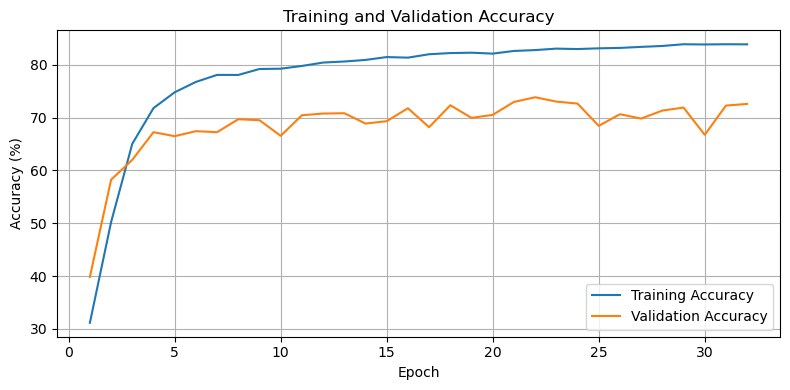

✅ Final Test Accuracy: 77.08%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.85      0.97      0.91       318
     burping       0.84      0.89      0.87       317
  discomfort       0.76      0.89      0.82       318
      hungry       0.51      0.26      0.35       318
       tired       0.76      0.84      0.80       317

    accuracy                           0.77      1588
   macro avg       0.74      0.77      0.75      1588
weighted avg       0.74      0.77      0.75      1588



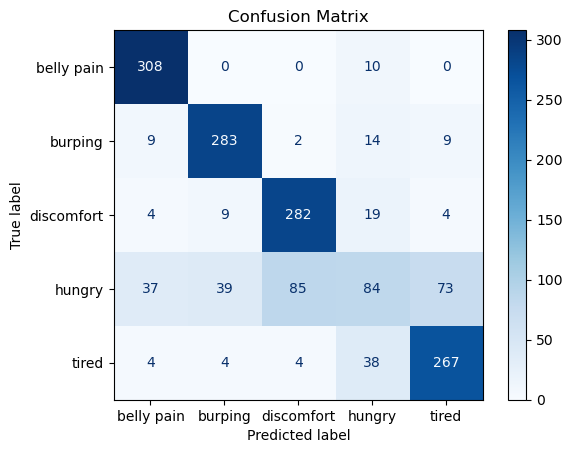


🧪 Final Validation Accuracy: 73.87%
✅ Final Test Accuracy: 77.08%


In [16]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")



🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 70:15:15
Epoch 1/60 - Train Acc: 32.13% - Val Acc: 41.73%
Epoch 2/60 - Train Acc: 56.17% - Val Acc: 58.06%
Epoch 3/60 - Train Acc: 69.39% - Val Acc: 62.09%
Epoch 4/60 - Train Acc: 74.51% - Val Acc: 66.83%
Epoch 5/60 - Train Acc: 76.57% - Val Acc: 66.20%
Epoch 6/60 - Train Acc: 77.83% - Val Acc: 67.93%
Epoch 7/60 - Train Acc: 78.77% - Val Acc: 64.36%
Epoch 8/60 - Train Acc: 79.47% - Val Acc: 69.94%
Epoch 9/60 - Train Acc: 79.51% - Val Acc: 68.18%
Epoch 10/60 - Train Acc: 80.39% - Val Acc: 69.94%
Epoch 11/60 - Train Acc: 80.48% - Val Acc: 67.67%
Epoch 12/60 - Train Acc: 80.94% - Val Acc: 68.22%
Epoch 13/60 - Train Acc: 80.78% - Val Acc: 68.72%
⏹️ Early stopping triggered at epoch 13


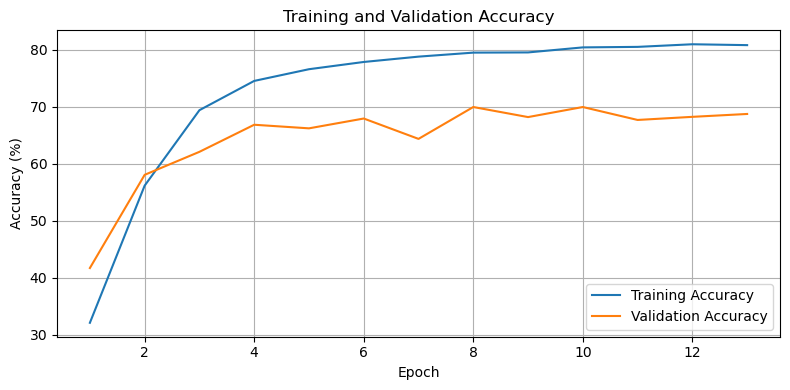

✅ Final Test Accuracy: 74.35%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.83      0.92      0.87       477
     burping       0.83      0.91      0.87       476
  discomfort       0.72      0.87      0.79       476
      hungry       0.41      0.20      0.27       477
       tired       0.75      0.82      0.78       476

    accuracy                           0.74      2382
   macro avg       0.71      0.74      0.72      2382
weighted avg       0.71      0.74      0.71      2382



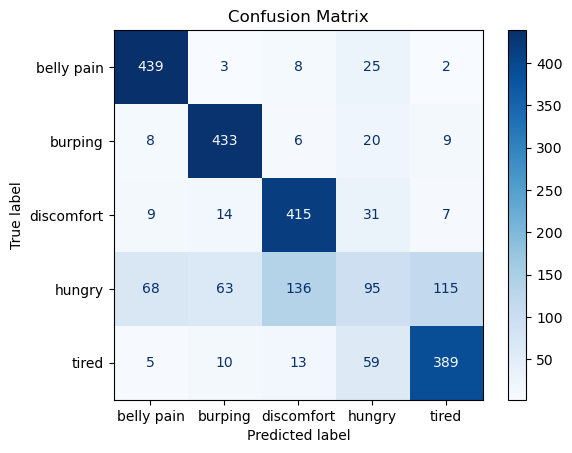


🧪 Final Validation Accuracy: 69.94%
✅ Final Test Accuracy: 74.35%


In [19]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.7, 0.15, 0.15))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")



🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 70:20:10
Epoch 1/60 - Train Acc: 33.47% - Val Acc: 41.77%
Epoch 2/60 - Train Acc: 54.57% - Val Acc: 59.43%
Epoch 3/60 - Train Acc: 68.21% - Val Acc: 67.80%
Epoch 4/60 - Train Acc: 73.52% - Val Acc: 66.64%
Epoch 5/60 - Train Acc: 76.12% - Val Acc: 70.13%
Epoch 6/60 - Train Acc: 77.32% - Val Acc: 67.67%
Epoch 7/60 - Train Acc: 78.25% - Val Acc: 69.18%
Epoch 8/60 - Train Acc: 78.99% - Val Acc: 68.24%
Epoch 9/60 - Train Acc: 79.13% - Val Acc: 68.05%
Epoch 10/60 - Train Acc: 79.59% - Val Acc: 68.52%
⏹️ Early stopping triggered at epoch 10


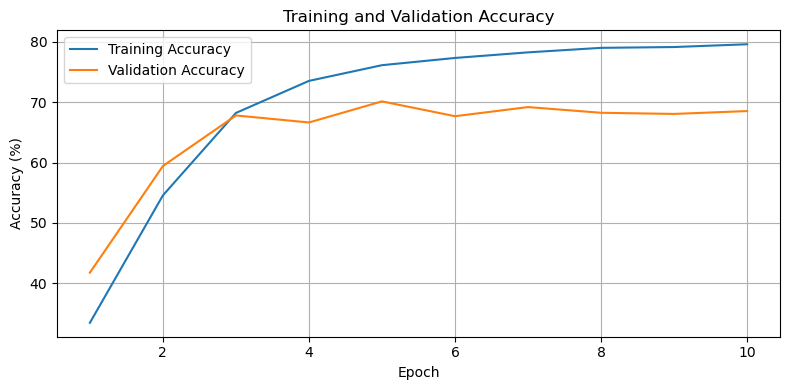

✅ Final Test Accuracy: 73.61%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.79      0.95      0.86       318
     burping       0.81      0.87      0.84       317
  discomfort       0.72      0.84      0.78       318
      hungry       0.46      0.18      0.26       318
       tired       0.73      0.84      0.78       317

    accuracy                           0.74      1588
   macro avg       0.70      0.74      0.70      1588
weighted avg       0.70      0.74      0.70      1588



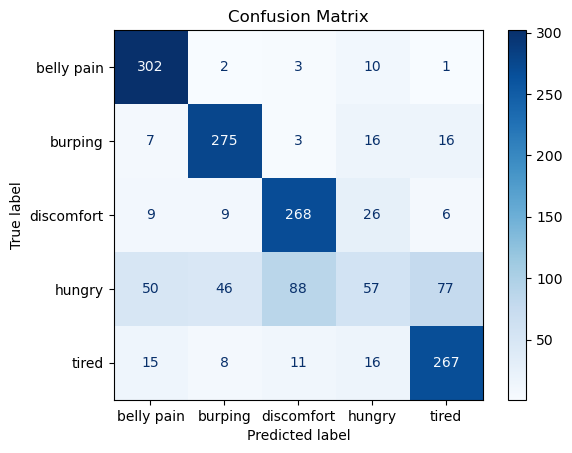


🧪 Final Validation Accuracy: 70.13%
✅ Final Test Accuracy: 73.61%


In [21]:
# E1 experiment: change split, optimizer, or learning rate

print("\n==========================")
print("🔬 Running: CNN | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.7, 0.2, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | SGD | 0.01 | 60 Epochs | Split 80:10:10
Epoch 1/60 - Train Acc: 19.96% - Val Acc: 20.03%
Epoch 2/60 - Train Acc: 19.91% - Val Acc: 19.96%
Epoch 3/60 - Train Acc: 19.96% - Val Acc: 19.96%
Epoch 4/60 - Train Acc: 19.67% - Val Acc: 19.96%
Epoch 5/60 - Train Acc: 20.44% - Val Acc: 20.03%
Epoch 6/60 - Train Acc: 20.53% - Val Acc: 20.03%
⏹️ Early stopping triggered at epoch 6


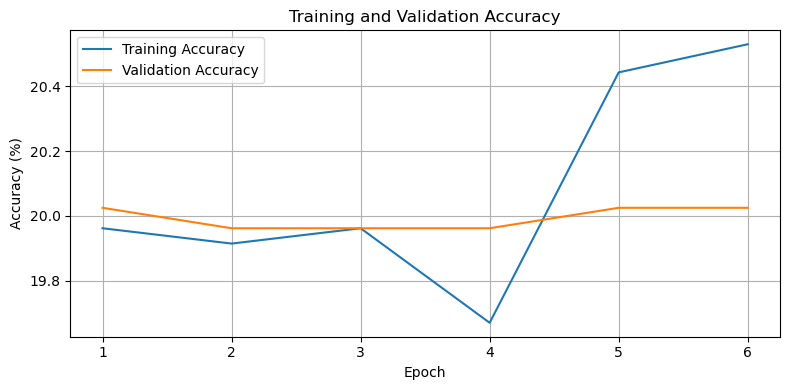

✅ Final Test Accuracy: 20.03%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.00      0.00      0.00       318
     burping       0.00      0.00      0.00       317
  discomfort       0.00      0.00      0.00       318
      hungry       0.20      1.00      0.33       318
       tired       0.00      0.00      0.00       317

    accuracy                           0.20      1588
   macro avg       0.04      0.20      0.07      1588
weighted avg       0.04      0.20      0.07      1588



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


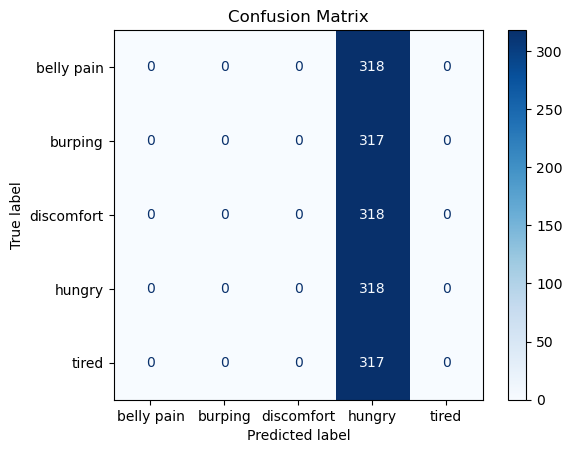


🧪 Final Validation Accuracy: 20.03%
✅ Final Test Accuracy: 20.03%


In [24]:


print("\n==========================")
print("🔬 Running: CNN | SGD | 0.01 | 60 Epochs | Split 80:10:10")
print("==========================")

train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.01, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | RMSprop | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60 - Train Acc: 39.03% - Val Acc: 46.91%
Epoch 2/60 - Train Acc: 61.46% - Val Acc: 65.43%
Epoch 3/60 - Train Acc: 71.81% - Val Acc: 68.39%
Epoch 4/60 - Train Acc: 75.43% - Val Acc: 62.59%
Epoch 5/60 - Train Acc: 76.75% - Val Acc: 70.84%
Epoch 6/60 - Train Acc: 77.56% - Val Acc: 65.43%
Epoch 7/60 - Train Acc: 78.79% - Val Acc: 68.95%
Epoch 8/60 - Train Acc: 79.02% - Val Acc: 71.22%
Epoch 9/60 - Train Acc: 79.38% - Val Acc: 69.84%
Epoch 10/60 - Train Acc: 79.86% - Val Acc: 72.10%
Epoch 11/60 - Train Acc: 80.29% - Val Acc: 71.41%
Epoch 12/60 - Train Acc: 80.75% - Val Acc: 66.88%
Epoch 13/60 - Train Acc: 81.20% - Val Acc: 70.21%
Epoch 14/60 - Train Acc: 81.53% - Val Acc: 71.41%
Epoch 15/60 - Train Acc: 81.92% - Val Acc: 72.04%
⏹️ Early stopping triggered at epoch 15


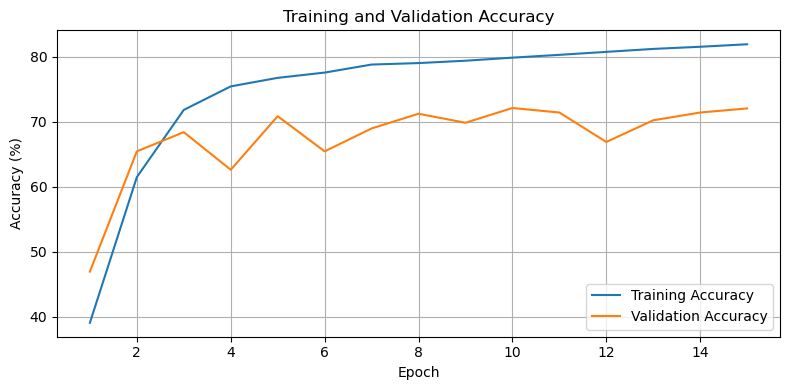

✅ Final Test Accuracy: 76.32%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.86      0.96      0.91       318
     burping       0.85      0.91      0.88       317
  discomfort       0.74      0.91      0.81       318
      hungry       0.47      0.26      0.33       318
       tired       0.76      0.78      0.77       317

    accuracy                           0.76      1588
   macro avg       0.73      0.76      0.74      1588
weighted avg       0.73      0.76      0.74      1588



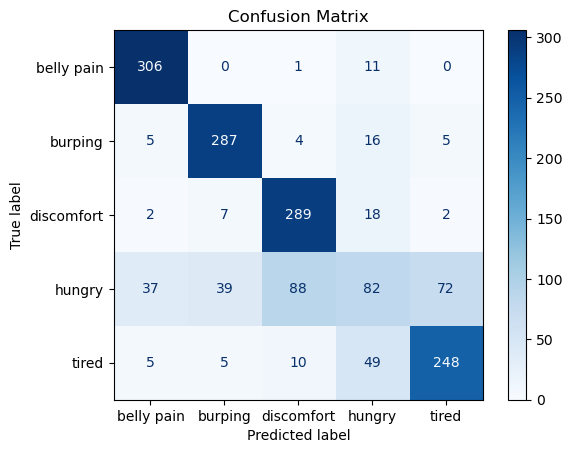


🧪 Final Validation Accuracy: 72.10%
✅ Final Test Accuracy: 76.32%


In [26]:
print("\n==========================")
print("🔬 Running: CNN | RMSprop | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")

train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="RMSprop", lr=0.001, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | Adam | 0.0005 | 60 Epochs | Split 80:10:10
Epoch 1/60 - Train Acc: 35.00% - Val Acc: 42.76%
Epoch 2/60 - Train Acc: 54.83% - Val Acc: 57.49%
Epoch 3/60 - Train Acc: 66.70% - Val Acc: 63.04%
Epoch 4/60 - Train Acc: 72.42% - Val Acc: 67.63%
Epoch 5/60 - Train Acc: 75.03% - Val Acc: 68.89%
Epoch 6/60 - Train Acc: 76.63% - Val Acc: 67.95%
Epoch 7/60 - Train Acc: 77.83% - Val Acc: 66.50%
Epoch 8/60 - Train Acc: 78.42% - Val Acc: 68.89%
Epoch 9/60 - Train Acc: 78.78% - Val Acc: 69.58%
Epoch 10/60 - Train Acc: 78.83% - Val Acc: 70.78%
Epoch 11/60 - Train Acc: 79.64% - Val Acc: 70.09%
Epoch 12/60 - Train Acc: 80.10% - Val Acc: 68.32%
Epoch 13/60 - Train Acc: 80.20% - Val Acc: 69.52%
Epoch 14/60 - Train Acc: 80.59% - Val Acc: 67.70%
Epoch 15/60 - Train Acc: 80.89% - Val Acc: 70.84%
Epoch 16/60 - Train Acc: 81.16% - Val Acc: 73.43%
Epoch 17/60 - Train Acc: 81.49% - Val Acc: 69.02%
Epoch 18/60 - Train Acc: 81.48% - Val Acc: 72.17%
Epoch 19/60 - Train Acc: 82.01% - Val Acc: 71.91

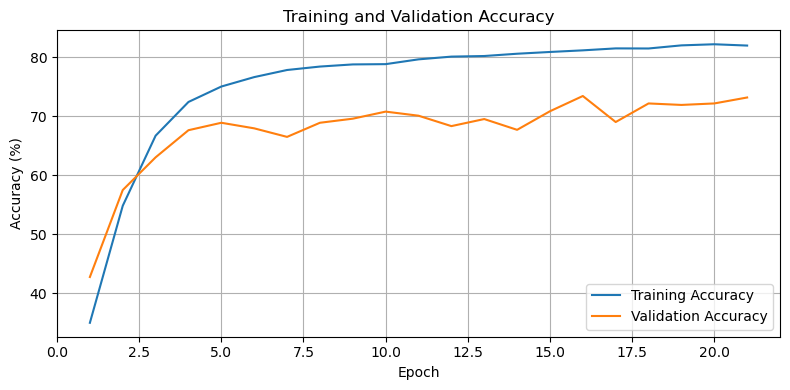

✅ Final Test Accuracy: 76.26%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.86      0.92      0.89       318
     burping       0.84      0.91      0.87       317
  discomfort       0.72      0.92      0.81       318
      hungry       0.48      0.23      0.31       318
       tired       0.76      0.84      0.80       317

    accuracy                           0.76      1588
   macro avg       0.73      0.76      0.74      1588
weighted avg       0.73      0.76      0.74      1588



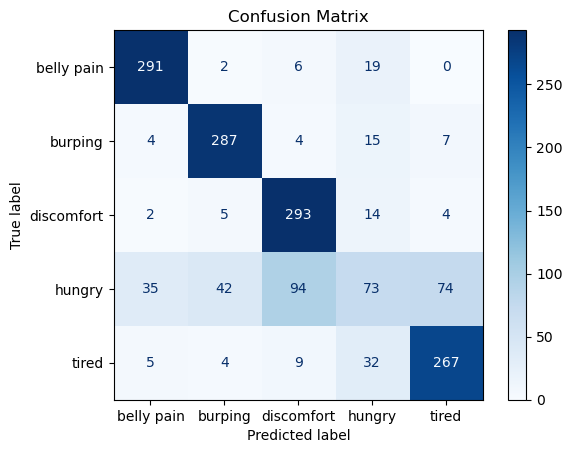


🧪 Final Validation Accuracy: 73.43%
✅ Final Test Accuracy: 76.26%


In [28]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.0005 | 60 Epochs | Split 80:10:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.0005, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | Adam | 0.0001 | 60 Epochs | Split 80:10:10
Epoch 1/60 - Train Acc: 33.82% - Val Acc: 39.74%
Epoch 2/60 - Train Acc: 44.53% - Val Acc: 46.73%
Epoch 3/60 - Train Acc: 52.32% - Val Acc: 50.25%
Epoch 4/60 - Train Acc: 57.76% - Val Acc: 54.85%
Epoch 5/60 - Train Acc: 62.41% - Val Acc: 57.12%
Epoch 6/60 - Train Acc: 65.88% - Val Acc: 61.21%
Epoch 7/60 - Train Acc: 68.40% - Val Acc: 62.22%
Epoch 8/60 - Train Acc: 70.88% - Val Acc: 66.62%
Epoch 9/60 - Train Acc: 72.85% - Val Acc: 61.59%
Epoch 10/60 - Train Acc: 73.84% - Val Acc: 61.65%
Epoch 11/60 - Train Acc: 75.50% - Val Acc: 64.04%
Epoch 12/60 - Train Acc: 76.35% - Val Acc: 64.36%
Epoch 13/60 - Train Acc: 76.83% - Val Acc: 65.18%
⏹️ Early stopping triggered at epoch 13


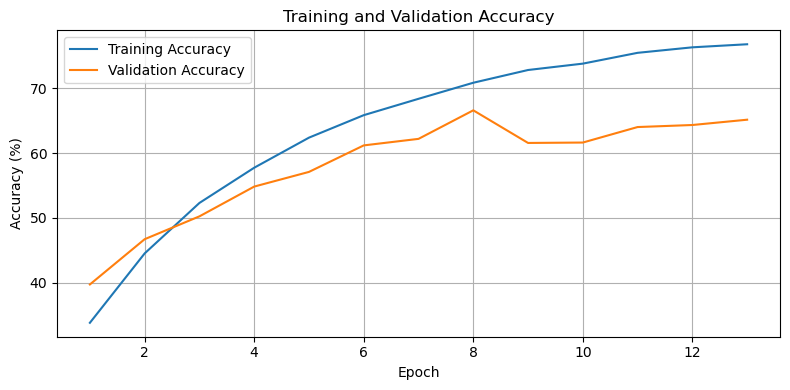

✅ Final Test Accuracy: 70.59%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.80      0.87      0.84       318
     burping       0.79      0.85      0.82       317
  discomfort       0.66      0.81      0.73       318
      hungry       0.45      0.17      0.25       318
       tired       0.66      0.82      0.73       317

    accuracy                           0.71      1588
   macro avg       0.68      0.71      0.67      1588
weighted avg       0.68      0.71      0.67      1588



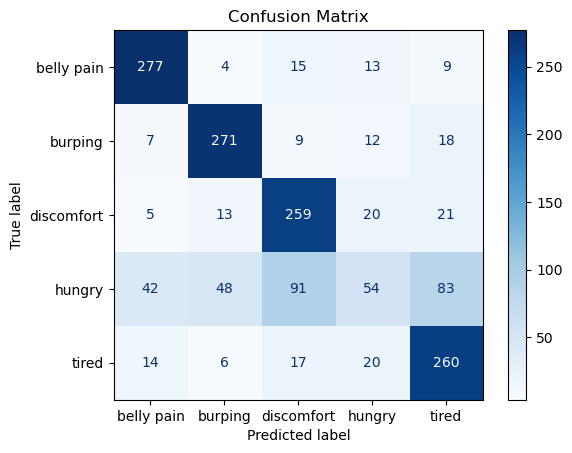


🧪 Final Validation Accuracy: 66.62%
✅ Final Test Accuracy: 70.59%


In [30]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.0001 | 60 Epochs | Split 80:10:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.0001, epochs=60)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | Adam | 0.001 | 20 Epochs | Split 80:10:10
Epoch 1/20 - Train Acc: 34.90% - Val Acc: 49.37%
Epoch 2/20 - Train Acc: 59.32% - Val Acc: 63.10%
Epoch 3/20 - Train Acc: 71.07% - Val Acc: 69.14%
Epoch 4/20 - Train Acc: 74.80% - Val Acc: 68.83%
Epoch 5/20 - Train Acc: 76.66% - Val Acc: 67.19%
Epoch 6/20 - Train Acc: 77.61% - Val Acc: 70.97%
Epoch 7/20 - Train Acc: 78.08% - Val Acc: 68.14%
Epoch 8/20 - Train Acc: 78.57% - Val Acc: 68.89%
Epoch 9/20 - Train Acc: 78.98% - Val Acc: 70.78%
Epoch 10/20 - Train Acc: 79.27% - Val Acc: 69.71%
Epoch 11/20 - Train Acc: 79.73% - Val Acc: 70.40%
⏹️ Early stopping triggered at epoch 11


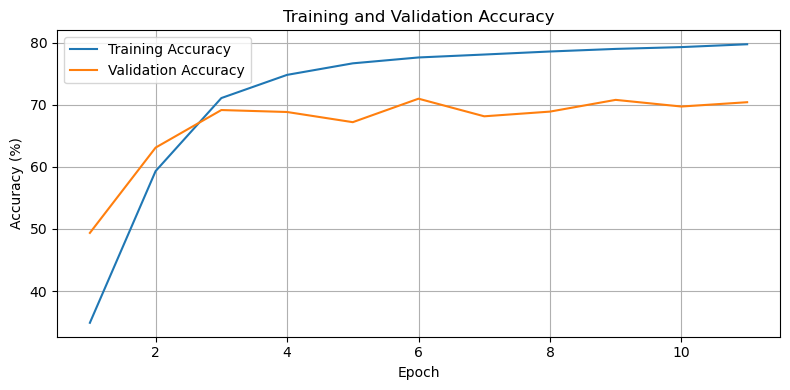

✅ Final Test Accuracy: 19.77%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.18      0.18      0.18       318
     burping       0.21      0.22      0.21       317
  discomfort       0.20      0.26      0.23       318
      hungry       0.26      0.13      0.17       318
       tired       0.18      0.20      0.19       317

    accuracy                           0.20      1588
   macro avg       0.20      0.20      0.20      1588
weighted avg       0.20      0.20      0.20      1588



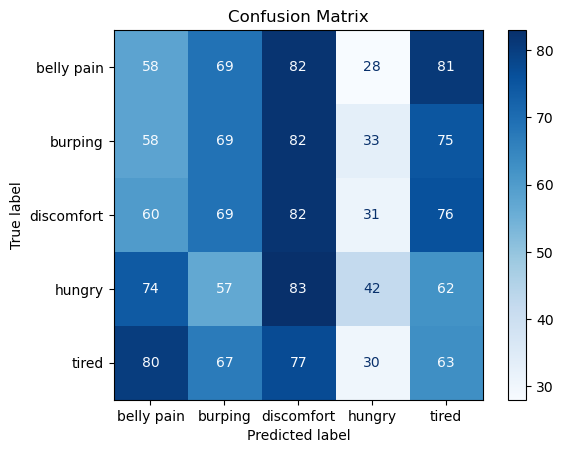


🧪 Final Validation Accuracy: 70.97%
✅ Final Test Accuracy: 19.77%


In [2]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.001 | 20 Epochs | Split 80:10:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=20)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")


🔬 Running: CNN | Adam | 0.001 | 40 Epochs | Split 80:10:10
Epoch 1/40 - Train Acc: 26.87% - Val Acc: 35.96%
Epoch 2/40 - Train Acc: 47.39% - Val Acc: 51.57%
Epoch 3/40 - Train Acc: 62.49% - Val Acc: 60.39%
Epoch 4/40 - Train Acc: 69.95% - Val Acc: 64.74%
Epoch 5/40 - Train Acc: 73.70% - Val Acc: 66.31%
Epoch 6/40 - Train Acc: 75.61% - Val Acc: 68.45%
Epoch 7/40 - Train Acc: 77.07% - Val Acc: 67.51%
Epoch 8/40 - Train Acc: 77.41% - Val Acc: 69.33%
Epoch 9/40 - Train Acc: 78.50% - Val Acc: 70.34%
Epoch 10/40 - Train Acc: 78.53% - Val Acc: 70.97%
Epoch 11/40 - Train Acc: 78.84% - Val Acc: 68.07%
Epoch 12/40 - Train Acc: 79.39% - Val Acc: 68.64%
Epoch 13/40 - Train Acc: 79.83% - Val Acc: 65.87%
Epoch 14/40 - Train Acc: 79.99% - Val Acc: 70.47%
Epoch 15/40 - Train Acc: 80.09% - Val Acc: 67.00%
⏹️ Early stopping triggered at epoch 15


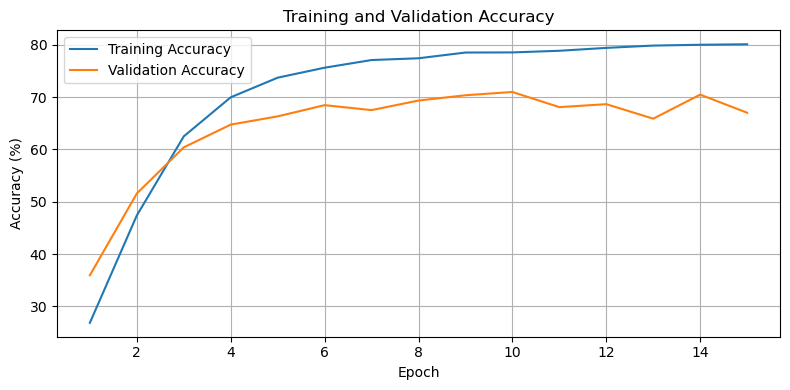

✅ Final Test Accuracy: 20.97%

📊 Classification Report:
              precision    recall  f1-score   support

  belly pain       0.21      0.24      0.22       318
     burping       0.20      0.20      0.20       317
  discomfort       0.22      0.27      0.25       318
      hungry       0.21      0.10      0.14       318
       tired       0.20      0.24      0.22       317

    accuracy                           0.21      1588
   macro avg       0.21      0.21      0.20      1588
weighted avg       0.21      0.21      0.20      1588



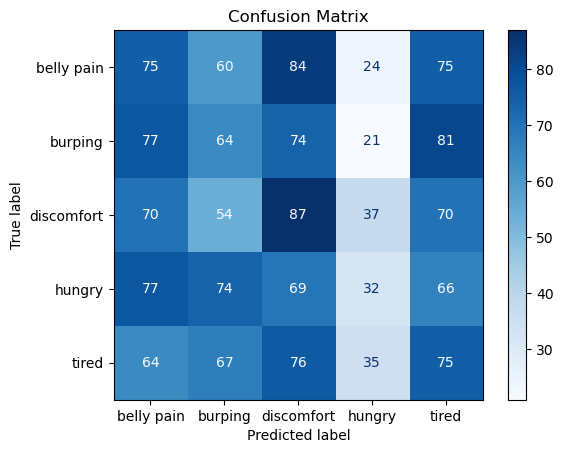


🧪 Final Validation Accuracy: 70.97%
✅ Final Test Accuracy: 20.97%


In [3]:
# ========== RUN A SINGLE EXPERIMENT ==========
print("\n==========================")
print("🔬 Running: CNN | Adam | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
train_loader, val_loader, test_loader, y_test = get_data_loaders((0.8, 0.1, 0.1))
cnn = CNN(num_classes=NUM_CLASSES)
trained_cnn, best_val_acc = train_model(cnn, train_loader, val_loader, optimizer_type="Adam", lr=0.001, epochs=40)
test_acc = evaluate_model(trained_cnn, test_loader, y_test.numpy())

print(f"\n🧪 Final Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

## SAVE MODEL CNN

In [4]:
torch.save(trained_cnn, "cnn_model_full.pth")
print("📦 Full CNN model saved as cnn_model_full.pth")


📦 Full CNN model saved as cnn_model_full.pth


In [ ]:
model = torch.load("cnn_model_full.pth")
print(model)


In [ ]:
# Inside your train_model function after best_model = deepcopy(...)
BEST_MODEL_PATH = "best_cnn_model.pth"

...

if val_acc > best_val_acc:
    best_val_acc = val_acc
    best_model = deepcopy(model.state_dict())
    no_improve_epochs = 0

    # 🔽 Save best model to disk
    torch.save(best_model, BEST_MODEL_PATH)


# SECTION 2: CNN-LSTM

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, Adamax, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# ========== LOAD & PREPARE DATA ==========
X = np.load("X_balanced.npy", mmap_mode='r')
y = np.load("y_balanced.npy")

X = X / np.max(X)
X = X[..., np.newaxis]
y_cat = to_categorical(y, num_classes=5)
class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]

# Function to allow split tuning
def split_data(split_ratio=(0.8, 0.1, 0.1)):
    X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
    val_fraction = split_ratio[1] / (split_ratio[0] + split_ratio[1])
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_fraction, stratify=y_temp.argmax(1), random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# ========== ATTENTION LAYER ==========
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# ========== MODEL ==========
def build_cnn_lstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)

# ========== UNIVERSAL RUNNER FUNCTION ==========
def run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, patience=5, batch_size=16, split_ratio=(0.8, 0.1, 0.1)):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(split_ratio=split_ratio)
    
    model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=5)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop], verbose=1)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
794/794 [==============================] - 330s 407ms/step - loss: 1.6018 - accuracy: 0.2196 - val_loss: 1.5458 - val_accuracy: 0.2846
Epoch 2/60
794/794 [==============================] - 319s 402ms/step - loss: 1.4247 - accuracy: 0.3571 - val_loss: 1.2580 - val_accuracy: 0.4572
Epoch 3/60
794/794 [==============================] - 302s 380ms/step - loss: 1.1651 - accuracy: 0.5022 - val_loss: 0.9905 - val_accuracy: 0.5938
Epoch 4/60
794/794 [==============================] - 297s 374ms/step - loss: 0.8859 - accuracy: 0.6335 - val_loss: 0.8067 - val_accuracy: 0.6788
Epoch 5/60
794/794 [==============================] - 295s 372ms/step - loss: 0.7446 - accuracy: 0.6895 - val_loss: 0.6927 - val_accuracy: 0.7110
Epoch 6/60
794/794 [==============================] - 304s 383ms/step - loss: 0.6607 - accuracy: 0.7202 - val_loss: 0.6576 - val_accuracy: 0.7103
Epoch 7/60
794/794 [==============================] - 308s 

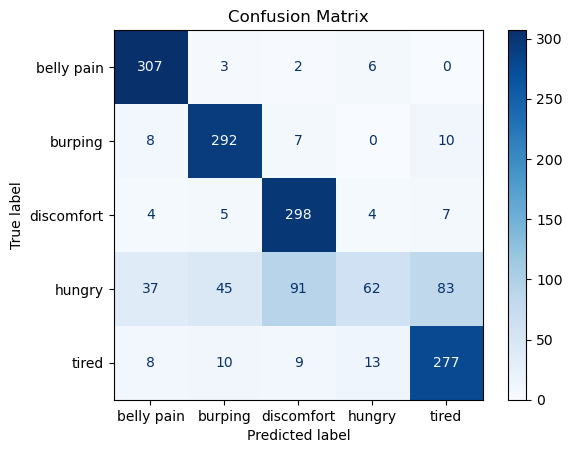

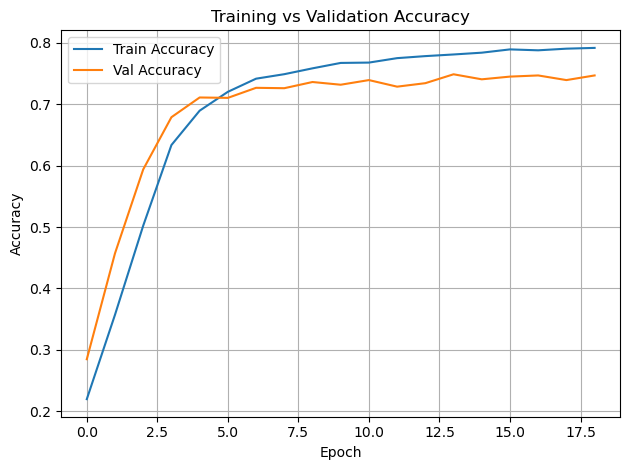

In [6]:

print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, split_ratio=(0.8, 0.1, 0.1))



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15
Epoch 1/60
695/695 [==============================] - 296s 411ms/step - loss: 1.5781 - accuracy: 0.2482 - val_loss: 1.5454 - val_accuracy: 0.2880
Epoch 2/60
695/695 [==============================] - 270s 388ms/step - loss: 1.4144 - accuracy: 0.3619 - val_loss: 1.3511 - val_accuracy: 0.4123
Epoch 3/60
695/695 [==============================] - 264s 379ms/step - loss: 1.1566 - accuracy: 0.5079 - val_loss: 1.0143 - val_accuracy: 0.5961
Epoch 4/60
695/695 [==============================] - 266s 383ms/step - loss: 0.8962 - accuracy: 0.6272 - val_loss: 0.8455 - val_accuracy: 0.6516
Epoch 5/60
695/695 [==============================] - 263s 379ms/step - loss: 0.7406 - accuracy: 0.7001 - val_loss: 0.7504 - val_accuracy: 0.6990
Epoch 6/60
695/695 [==============================] - 266s 383ms/step - loss: 0.6569 - accuracy: 0.7234 - val_loss: 0.7206 - val_accuracy: 0.7024
Epoch 7/60
695/695 [==============================] - 264s 

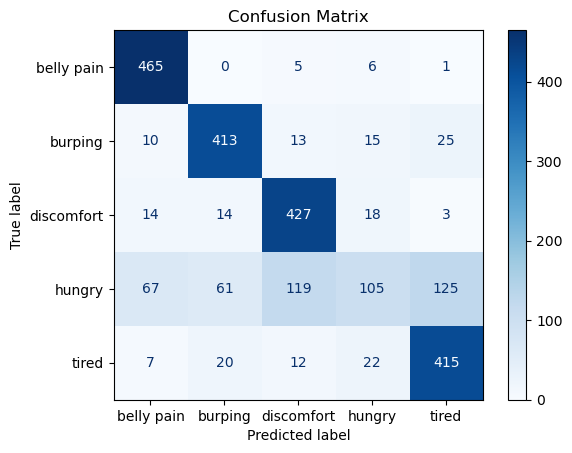

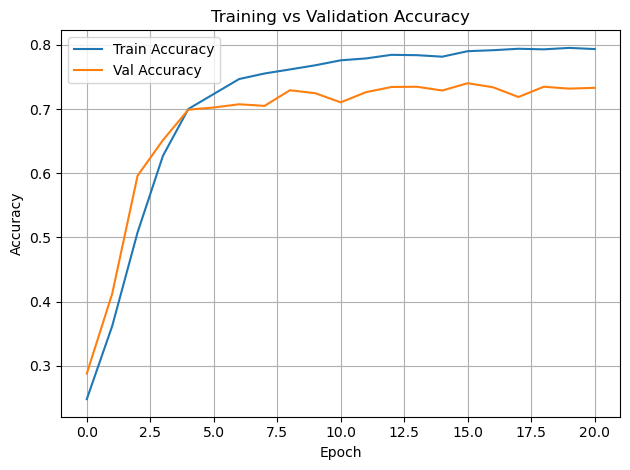

In [7]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, split_ratio=(0.7, 0.15, 0.15))


In [28]:
# ========== ATTENTION LAYER ==========
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# ========== MODEL ==========
def build_cnn_lstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)


# ========== UNIVERSAL RUNNER FUNCTION ==========
def run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, patience=5, batch_size=32, split_ratio=(0.8, 0.1, 0.1)):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(split_ratio=split_ratio)
    
    model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=5)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop], verbose=1)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - 258s 716ms/step - loss: 1.6075 - accuracy: 0.2139 - val_loss: 1.5899 - val_accuracy: 0.2575
Epoch 2/60
348/348 [==============================] - 234s 673ms/step - loss: 1.5486 - accuracy: 0.2888 - val_loss: 1.4772 - val_accuracy: 0.3475
Epoch 3/60
348/348 [==============================] - 238s 682ms/step - loss: 1.4110 - accuracy: 0.3844 - val_loss: 1.3083 - val_accuracy: 0.4265
Epoch 4/60
348/348 [==============================] - 231s 664ms/step - loss: 1.2220 - accuracy: 0.4916 - val_loss: 1.1208 - val_accuracy: 0.5392
Epoch 5/60
348/348 [==============================] - 230s 661ms/step - loss: 1.0160 - accuracy: 0.5836 - val_loss: 0.9358 - val_accuracy: 0.6239
Epoch 6/60
348/348 [==============================] - 230s 662ms/step - loss: 0.8610 - accuracy: 0.6468 - val_loss: 0.8245 - val_accuracy: 0.6692
Epoch 7/60
348/348 [==============================] - 237s 

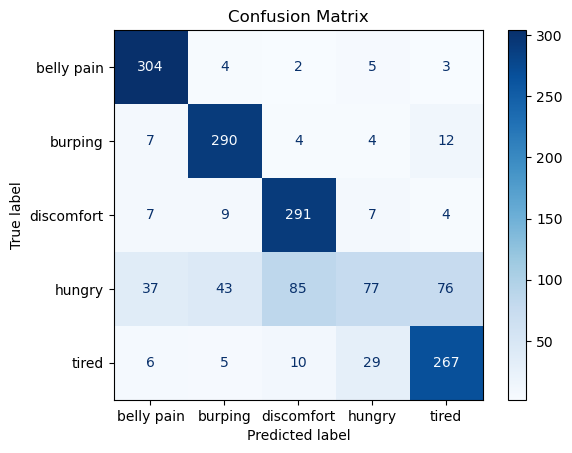

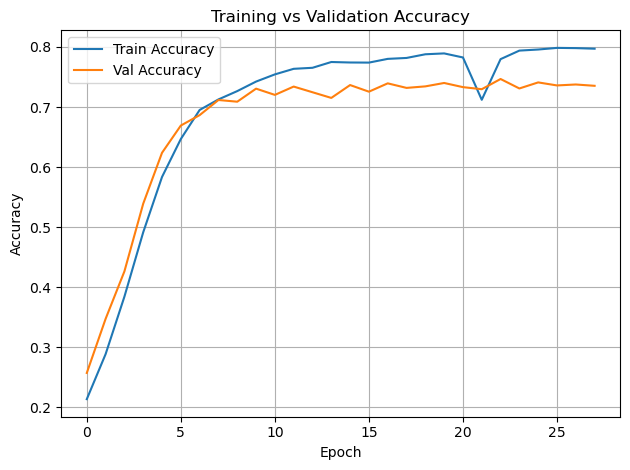

In [9]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=5,
    split_ratio=(0.7, 0.20, 0.10)
)



🔬 Running: CNN-LSTM | SGD | 0.01 | 60 Epochs | Split 80:10:10
Epoch 1/60
199/199 [==============================] - 317s 2s/step - loss: 1.6098 - accuracy: 0.1951 - val_loss: 1.6095 - val_accuracy: 0.2072
Epoch 2/60
199/199 [==============================] - 301s 2s/step - loss: 1.6097 - accuracy: 0.1987 - val_loss: 1.6095 - val_accuracy: 0.1996
Epoch 3/60
199/199 [==============================] - 300s 2s/step - loss: 1.6097 - accuracy: 0.1984 - val_loss: 1.6094 - val_accuracy: 0.2003
Epoch 4/60
199/199 [==============================] - 299s 2s/step - loss: 1.6095 - accuracy: 0.2020 - val_loss: 1.6094 - val_accuracy: 0.2003
Epoch 5/60
199/199 [==============================] - 299s 2s/step - loss: 1.6096 - accuracy: 0.2010 - val_loss: 1.6092 - val_accuracy: 0.2028
Epoch 6/60
199/199 [==============================] - 300s 2s/step - loss: 1.6094 - accuracy: 0.2005 - val_loss: 1.6092 - val_accuracy: 0.2072

🧪 Final Validation Accuracy: 20.72%
✅ Final Test Accuracy: 20.40%
50/50 [=====

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


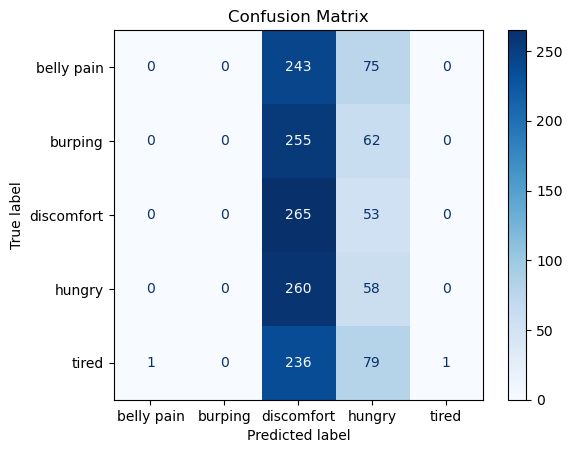

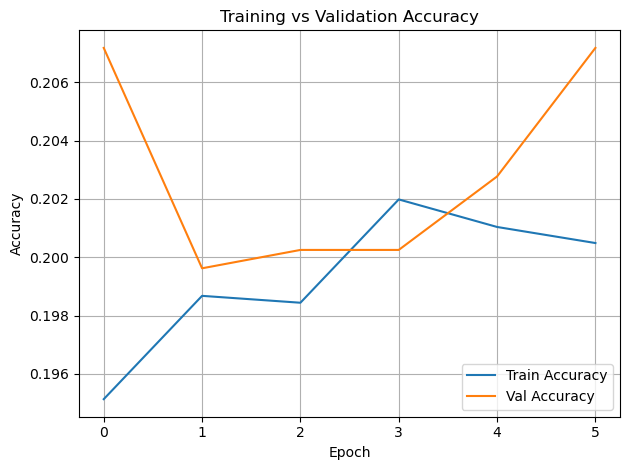

In [10]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | SGD | 0.01 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="SGD",
    lr=0.01,
    epochs=60,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)



🔬 Running: CNN-LSTM | RMSprop | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
199/199 [==============================] - 330s 2s/step - loss: 1.6096 - accuracy: 0.2075 - val_loss: 1.6064 - val_accuracy: 0.2368
Epoch 2/60
199/199 [==============================] - 311s 2s/step - loss: 1.5824 - accuracy: 0.2598 - val_loss: 1.5394 - val_accuracy: 0.2960
Epoch 3/60
199/199 [==============================] - 306s 2s/step - loss: 1.5317 - accuracy: 0.2927 - val_loss: 1.5084 - val_accuracy: 0.2935
Epoch 4/60
199/199 [==============================] - 324s 2s/step - loss: 1.4928 - accuracy: 0.3172 - val_loss: 1.4821 - val_accuracy: 0.3205
Epoch 5/60
199/199 [==============================] - 315s 2s/step - loss: 1.4453 - accuracy: 0.3500 - val_loss: 1.4886 - val_accuracy: 0.3275
Epoch 6/60
199/199 [==============================] - 280s 1s/step - loss: 1.3835 - accuracy: 0.3885 - val_loss: 1.3309 - val_accuracy: 0.4074
Epoch 7/60
199/199 [==============================] - 234s 1s/step - loss:

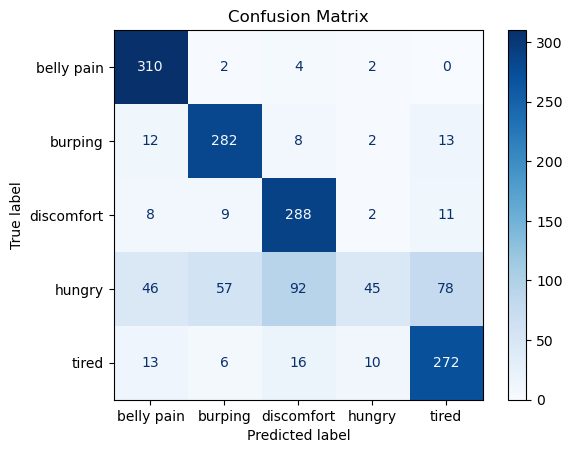

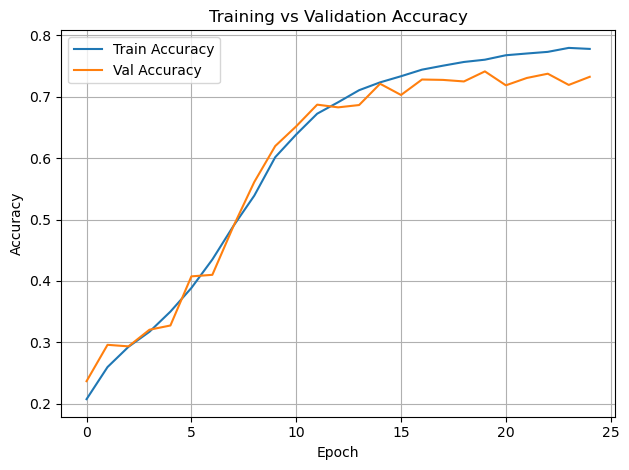

In [11]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.001,
    epochs=60,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)



🔬 Running: CNN-LSTM |Adam | 0.0005 | 60 Epochs | Split 80:10:10
Epoch 1/60
199/199 [==============================] - 242s 1s/step - loss: 1.6021 - accuracy: 0.2134 - val_loss: 1.5827 - val_accuracy: 0.2620
Epoch 2/60
199/199 [==============================] - 225s 1s/step - loss: 1.5417 - accuracy: 0.2760 - val_loss: 1.5038 - val_accuracy: 0.3035
Epoch 3/60
199/199 [==============================] - 222s 1s/step - loss: 1.4916 - accuracy: 0.3143 - val_loss: 1.4740 - val_accuracy: 0.3306
Epoch 4/60
199/199 [==============================] - 223s 1s/step - loss: 1.4503 - accuracy: 0.3323 - val_loss: 1.4071 - val_accuracy: 0.3520
Epoch 5/60
199/199 [==============================] - 221s 1s/step - loss: 1.4150 - accuracy: 0.3611 - val_loss: 1.3795 - val_accuracy: 0.3634
Epoch 6/60
199/199 [==============================] - 222s 1s/step - loss: 1.3682 - accuracy: 0.3894 - val_loss: 1.4007 - val_accuracy: 0.3948
Epoch 7/60
199/199 [==============================] - 221s 1s/step - loss: 1.

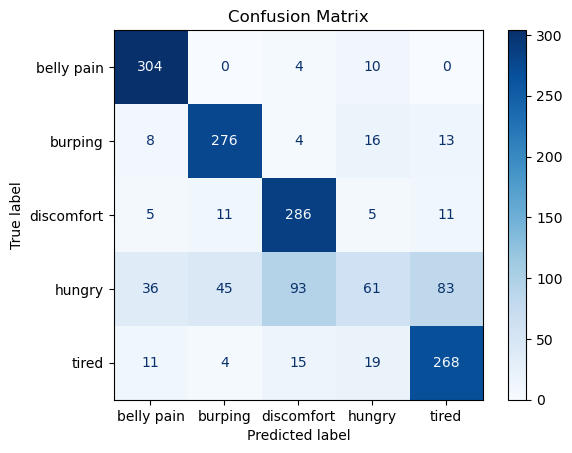

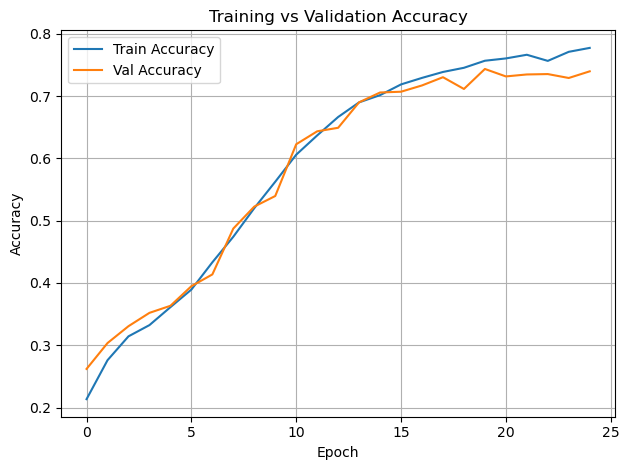

In [12]:
print("\n==========================")
print("🔬 Running: CNN-LSTM |Adam | 0.0005 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0005,
    epochs=60,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.0001 | 60 Epochs | Split 80:10:10
Epoch 1/60
199/199 [==============================] - 240s 1s/step - loss: 1.6103 - accuracy: 0.2003 - val_loss: 1.6087 - val_accuracy: 0.2015
Epoch 2/60
199/199 [==============================] - 227s 1s/step - loss: 1.6085 - accuracy: 0.2076 - val_loss: 1.6067 - val_accuracy: 0.2890
Epoch 3/60
199/199 [==============================] - 225s 1s/step - loss: 1.5900 - accuracy: 0.2454 - val_loss: 1.5443 - val_accuracy: 0.2790
Epoch 4/60
199/199 [==============================] - 224s 1s/step - loss: 1.5463 - accuracy: 0.2791 - val_loss: 1.5275 - val_accuracy: 0.2979
Epoch 5/60
199/199 [==============================] - 224s 1s/step - loss: 1.5180 - accuracy: 0.2984 - val_loss: 1.5056 - val_accuracy: 0.3130
Epoch 6/60
199/199 [==============================] - 223s 1s/step - loss: 1.5095 - accuracy: 0.3031 - val_loss: 1.4941 - val_accuracy: 0.3111
Epoch 7/60
199/199 [==============================] - 224s 1s/step - loss: 1

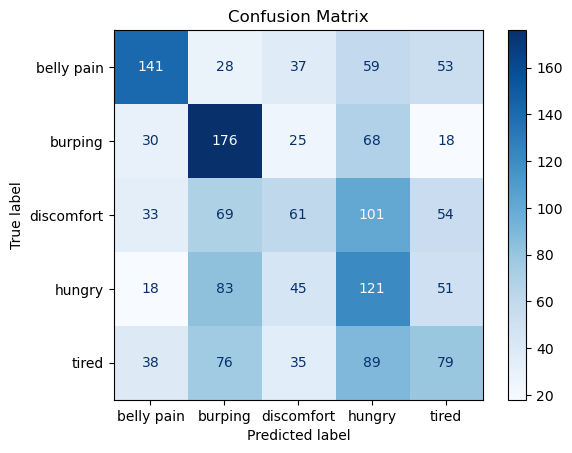

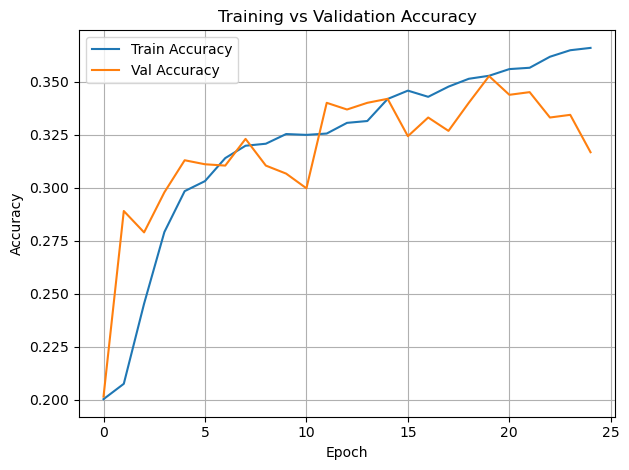

In [13]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.0001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0001,
    epochs=60,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.001 | 20 Epochs | Split 80:10:10
Epoch 1/20
199/199 [==============================] - 329s 2s/step - loss: 1.6086 - accuracy: 0.2066 - val_loss: 1.5893 - val_accuracy: 0.2972
Epoch 2/20
199/199 [==============================] - 307s 2s/step - loss: 1.5426 - accuracy: 0.2957 - val_loss: 1.4698 - val_accuracy: 0.3249
Epoch 3/20
199/199 [==============================] - 305s 2s/step - loss: 1.4134 - accuracy: 0.3599 - val_loss: 1.3200 - val_accuracy: 0.4018
Epoch 4/20
199/199 [==============================] - 305s 2s/step - loss: 1.2385 - accuracy: 0.4676 - val_loss: 1.1039 - val_accuracy: 0.5390
Epoch 5/20
199/199 [==============================] - 305s 2s/step - loss: 1.0368 - accuracy: 0.5727 - val_loss: 0.9270 - val_accuracy: 0.6234
Epoch 6/20
199/199 [==============================] - 305s 2s/step - loss: 0.8565 - accuracy: 0.6474 - val_loss: 0.8003 - val_accuracy: 0.6814
Epoch 7/20
199/199 [==============================] - 305s 2s/step - loss: 0.

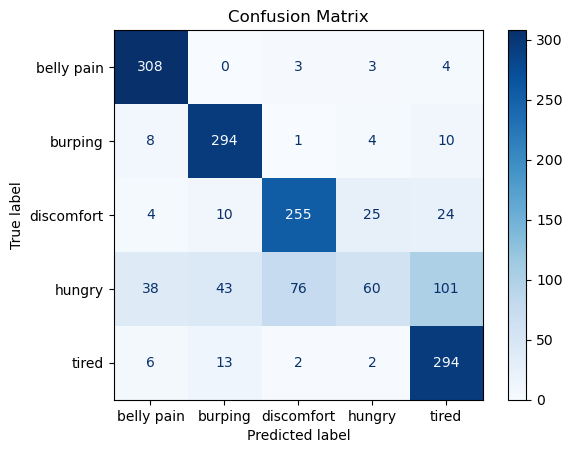

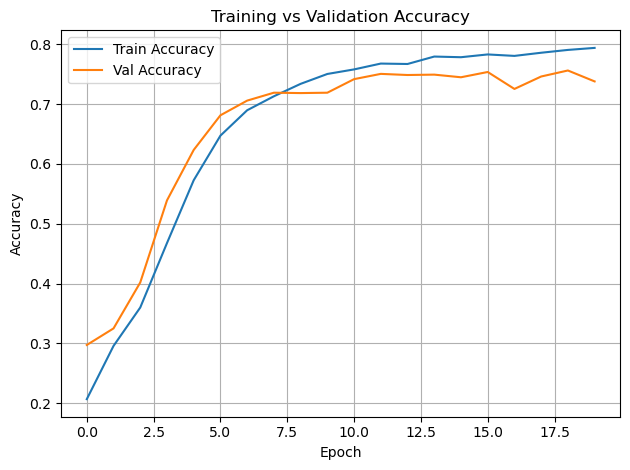

In [14]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 20 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=20,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10
Epoch 1/40
199/199 [==============================] - 301s 1s/step - loss: 1.6059 - accuracy: 0.2114 - val_loss: 1.5753 - val_accuracy: 0.2601
Epoch 2/40
199/199 [==============================] - 323s 2s/step - loss: 1.5268 - accuracy: 0.2922 - val_loss: 1.4375 - val_accuracy: 0.3526
Epoch 3/40
199/199 [==============================] - 304s 2s/step - loss: 1.4182 - accuracy: 0.3626 - val_loss: 1.3182 - val_accuracy: 0.4225
Epoch 4/40
199/199 [==============================] - 323s 2s/step - loss: 1.2692 - accuracy: 0.4500 - val_loss: 1.1864 - val_accuracy: 0.4780
Epoch 5/40
199/199 [==============================] - 322s 2s/step - loss: 1.0775 - accuracy: 0.5486 - val_loss: 0.9795 - val_accuracy: 0.5730
Epoch 6/40
199/199 [==============================] - 306s 2s/step - loss: 0.8882 - accuracy: 0.6286 - val_loss: 0.8495 - val_accuracy: 0.6366
Epoch 7/40
199/199 [==============================] - 307s 2s/step - loss: 0.

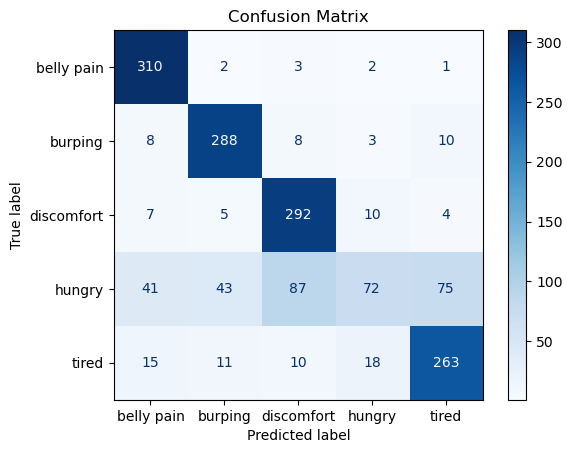

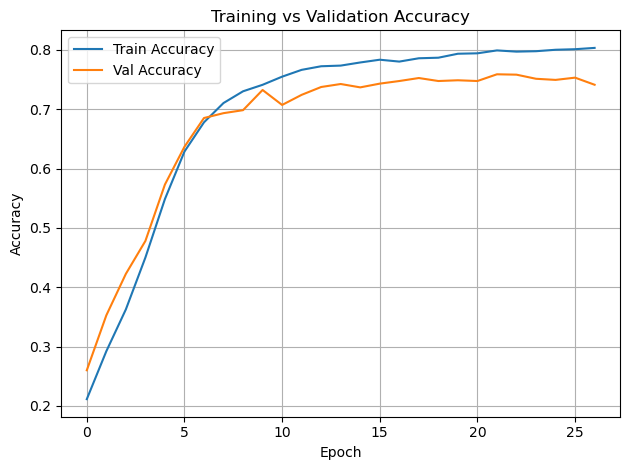

In [35]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=40,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)

# save best model

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, patience=5, batch_size=16, split_ratio=(0.8, 0.1, 0.1)):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(split_ratio=split_ratio)
    
    model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=5)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # 🛑 EarlyStopping
    early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)

    # 💾 Save the best model
    checkpoint = ModelCheckpoint(
        filepath="best_model_CNNLSTM.h5",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )

    # 🏃‍♀️ Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # ✅ Evaluation
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("📦 Best CNN-LSTM model automatically saved as 'best_model_CNNLSTM2.h5'")


In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=40,
    batch_size=64,
    patience=5,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10
Epoch 1/40
199/199 [==============================] - ETA: 0s - loss: 1.6093 - accuracy: 0.2086
Epoch 1: val_accuracy improved from -inf to 0.26008, saving model to best_model_CNNLSTM.h5
199/199 [==============================] - 277s 1s/step - loss: 1.6093 - accuracy: 0.2086 - val_loss: 1.6048 - val_accuracy: 0.2601
Epoch 2/40
199/199 [==============================] - ETA: 0s - loss: 1.5600 - accuracy: 0.2752
Epoch 2: val_accuracy improved from 0.26008 to 0.32620, saving model to best_model_CNNLSTM.h5
199/199 [==============================] - 272s 1s/step - loss: 1.5600 - accuracy: 0.2752 - val_loss: 1.4769 - val_accuracy: 0.3262
Epoch 3/40
199/199 [==============================] - ETA: 0s - loss: 1.4405 - accuracy: 0.3504
Epoch 3: val_accuracy improved from 0.32620 to 0.37531, saving model to best_model_CNNLSTM.h5
199/199 [==============================] - 435s 2s/step - loss: 1.4405 - accuracy: 0.3504 - val_loss: 1.

In [45]:
split_ratio = (0.8, 0.1, 0.1) 

X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
val_fraction = split_ratio[1] / (split_ratio[0] + split_ratio[1])
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_fraction, stratify=y_temp.argmax(1), random_state=42)
model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=5)
model.save("best_model_CNNLSTM.h5")
print("✅ Best CNN-LSTM model saved as 'best_model_CNNLSTM.h5'")

✅ Best CNN-LSTM model saved as 'best_model_CNNLSTM.h5'


# SECTION 3: RESLSTM MODEL TRAINING

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout, BatchNormalization, ReLU, Add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, Adamax
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


# === Custom Attention Layer ===
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# === ResLSTM WITH ATTENTION ===
def residual_block(x, filters, stride):
    shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding='same')(x)
    shortcut = BatchNormalization()(shortcut)

    x = Conv2D(filters, kernel_size=(3, 3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = ReLU()(x)
    return x

def build_reslstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, kernel_size=(7, 7), strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    for filters, stride in zip([32, 64, 128], [2, 1, 1]):
        x = residual_block(x, filters, stride)
        x = Dropout(0.3)(x)

    x = Reshape((x.shape[1], x.shape[2]*x.shape[3]))(x)
    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)

    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)

# === Universal Run Function for CNN-LSTM or ResLSTM ===
def run_attention_model(model_type="reslstm", optimizer_name="Adam", lr=0.001, epochs=60, split_ratio=(0.8, 0.1, 0.1), batch_size=32):
    X = np.load("X_final.npy")
    y = np.load("y_final.npy")
    X = X / np.max(X)
    X = X[..., np.newaxis]

    class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]
    num_classes = len(np.unique(y))
    y_cat = to_categorical(y, num_classes)

    X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=split_ratio[1]/(split_ratio[0]+split_ratio[1]), stratify=y_temp.argmax(1), random_state=42)

    if model_type == "reslstm":
        model = build_reslstm_attention(X_train.shape[1:], num_classes)
    else:
        model = build_cnn_lstm_attention(X_train.shape[1:], num_classes)

    if optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    else:
        optimizer = Adam(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Add this before model.fit
    checkpoint = ModelCheckpoint(
        filepath='best_model_ResLSTM.h5' if model_type == 'reslstm' else 'best_model_CNNLSTM.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
   
    callbacks=[early_stop, checkpoint]

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=epochs, batch_size=batch_size, verbose=1,
                    callbacks=[early_stop, checkpoint])


    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.8, 0.1, 0.1),
    batch_size=32
)


In [ ]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.15, 0.15),
    batch_size=32
)


In [ ]:
print("\n==========================")
print("🔬 Running: ResLSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_attention_model(
    model_type="reslstm",
    optimizer_name="Adam", 
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.2, 0.1),
    batch_size=32
)


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model

# Get best epoch from previous training
val_accuracies = history.history['val_accuracy']
best_epoch = np.argmax(val_accuracies) + 1
print(f"🔍 Best epoch: {best_epoch} with val_accuracy = {val_accuracies[best_epoch - 1]:.4f}")

# Rebuild and retrain ResLSTM model
model = build_reslstm_attention(X_train.shape[1:], num_classes=5)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=best_epoch,
    batch_size=32,
    verbose=1
)

# Save best ResLSTM model
model.save('best_reslstm_model.h5')
print("✅ Best ResLSTM model saved as 'best_reslstm_model.h5'")
